[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter7_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 7: Value-at-Risk and Expected Shortfall

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook computes the charts and tables of Chapter 7 on real daily data: S&P 500, BET, Bitcoin, EUR/RON, gold and a portfolio of SPY, TLT, GLD and Bitcoin.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_7'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/2026 MFM/MFM/notebooks/EN


In [2]:
# On Colab, install arch first: !pip install arch
import os
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate, signal
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [3]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Brand colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'   # reference lines, bands and grid only
LightGray = '#DADADA'
Teal     = '#17A2B8'
METHOD_COL = {'HS': MainBlue, 'Normal': Orange, 'Student-t': Forest, 'Cornish-Fisher': Purple, 'EVT (GPD)': IDAred}

HERE = '.'
SEED = 42
ORDER = ['sp500', 'bet', 'btc', 'eurron', 'gold']
METHODS = ['HS', 'Normal', 'Student-t', 'Cornish-Fisher', 'EVT (GPD)']
B_BOOT = 2000


def save_fig(name):
    """Save the figure as a transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)



import tempfile
# with SAVE_TO_DRIVE = True (cell at the top), tables and charts are kept in OUT_DIR; otherwise in a temporary folder
KEEP = bool(globals().get('SAVE_TO_DRIVE', False))
HERE = globals().get('OUT_DIR', '.') if KEEP else tempfile.gettempdir()


def save_fig(name):
    """Show the figure; save it as PNG in OUT_DIR when SAVE_TO_DRIVE is on."""
    if KEEP:
        plt.savefig(os.path.join(HERE, name + '.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026: S&P 500, BET, Bitcoin, EUR/RON (BNR reference rate), gold (USD per troy ounce).
- Equity indices: weekdays only; holiday records (unchanged close, zero volume) removed, genuine unchanged closes kept; gold: weekdays only; Bitcoin: 7 days a week.
- Daily log return in %, $r_t = 100(\ln P_t - \ln P_{t-1})$; log loss $L = -r$; VaR and ES are positive numbers. In money, a log loss $L$ is $V(1 - e^{-L/100})$.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# use the local copy of the course data when the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# name -> (symbol, label, type, start date)
MARKETS = {
    'sp500':  ('GSPC.INDX',    'S&P 500',                  'index',  '2000-01-01'),
    'bet':    ('BET',          'BET',                      'index',  '2000-01-01'),
    'btc':    ('BTC-USD.CC',   'Bitcoin',                  'crypto', '2014-09-17'),
    'eurron': ('REF:EUR',      'EUR/RON (reference rate)', 'fx',     '2005-07-01'),
    'gold':   ('XAUUSD.FOREX', 'Gold (XAU/USD)',           'fx',     '2000-01-01'),
}
# portfolio assets (prices aligned on common days)
ASSETS = {
    'SPY': ('SPY.US', 'adjusted_close'), 'TLT': ('TLT.US', 'adjusted_close'), 'GLD': ('GLD.US', 'adjusted_close'),
    'BTC': ('BTC-USD.CC', 'close'),
    'TLV': ('TLV.RO', 'adjusted_close'), 'SNP': ('SNP.RO', 'adjusted_close'), 'BRD': ('BRD.RO', 'adjusted_close'),
    'TGN': ('TGN.RO', 'adjusted_close'), 'SNG': ('SNG.RO', 'adjusted_close'), 'SNN': ('SNN.RO', 'adjusted_close'),
    'EL': ('EL.RO', 'adjusted_close'), 'FP': ('FP.RO', 'adjusted_close'), 'TEL': ('TEL.RO', 'adjusted_close'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

_CACHE = {}


def read_market(symbol):
    """Read the daily price series of one symbol (local copy of the course data, else from GitHub)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official RON reference rate (annual BNR XML archives)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END):
    """Daily price, cleaned according to the chapter conventions."""
    symbol, _, kind, start0 = MARKETS[name]
    start = start or start0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    d = read_market(symbol).loc[start:end]
    d = d[d['close'] > 0].dropna(subset=['close'])
    if kind != 'crypto':
        d = d[d.index.dayofweek < 5]          # no weekend quotes
    s = d['close']
    if kind == 'index' and 'volume' in d:
        # drop holidays filled with the previous price: unchanged close and zero/missing volume
        s = s[~((s.diff() == 0) & (d['volume'].fillna(0) <= 0))]
    return s.rename(name)


def log_returns(name, start=None, end=END):
    """Log returns on the series' own calendar."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


def periods_per_year(r):
    """Actual frequency: average number of observations per calendar year."""
    return len(r) / ((r.index[-1] - r.index[0]).days / 365.25)


def asset_price(key, end=END):
    symbol, col = ASSETS[key]
    s = read_market(symbol)[col].loc[:end]
    s = s[s > 0].dropna()
    if key != 'BTC':
        s = s[s.index.dayofweek < 5]
    return s.rename(key)


def joint_returns(keys, start=None, end=END):
    """Log returns for several assets: align the PRICES on common days first, then compute returns."""
    p = pd.concat([asset_price(k, end) for k in keys], axis=1, join='inner').dropna()
    if start:
        p = p.loc[start:]
    return np.log(p).diff().dropna()


# daily log returns in %, loss L = -r
rets = {k: 100 * log_returns(k) for k in MARKETS}
loss = {k: -v for k, v in rets.items()}
for k in ORDER:
    print(f'{LABELS[k]:26s}', rets[k].index[0].date(), '->', rets[k].index[-1].date(), len(rets[k]), 'obs')

S&P 500                    2000-01-04 -> 2026-09-18 6717 obs
BET                        2000-01-06 -> 2026-09-18 6670 obs
Bitcoin                    2014-09-18 -> 2026-09-18 4384 obs
EUR/RON (reference rate)   2005-07-05 -> 2026-09-18 5352 obs
Gold (XAU/USD)             2000-01-04 -> 2026-09-18 6956 obs


## Risk measures

- VaR and ES by four methods: historical, Normal distribution, Student-$t$, Cornish–Fisher (`hs_var_es`, `normal_var_es`, `t_var_es`, `cf_var_es`).
- Historical convention: VaR = interpolated empirical $(1-\alpha)$-quantile of the loss; ES = mean of the losses at or above it (about $n\alpha$ losses; the exact plug-in of the integral would weight the boundary loss by $n\alpha - \lfloor n\alpha \rfloor$).
- Peaks over threshold: GPD fit, GPD VaR and ES, standard errors, mean excess (`gpd_fit`, `gpd_var_es`, `gpd_se`, `mean_excess`).
- AR(1)-GARCH(1,1) filtering, filtered historical simulation and conditional EVT (`garch_filter`, `garch_next`, `fhs_mc`, `rolling_conditional`).

In [5]:
def hs_var_es(L, alpha):
    """Historical simulation: VaR alpha = empirical (1 - alpha)-quantile of the loss; ES = mean of the losses beyond it."""
    L = np.asarray(L)
    v = np.quantile(L, 1 - alpha)
    return v, L[L >= v].mean()


def normal_var_es(L, alpha):
    """Distributia Normala: VaR = -mu_X + sigma z_{1-alpha}, ES = -mu_X + sigma phi(z_alpha)/alpha (mu_L = -mu_X)."""
    mu, s = np.mean(L), np.std(L, ddof=1)
    z = stats.norm.ppf(1 - alpha)
    return mu + s * z, mu + s * stats.norm.pdf(z) / alpha


def t_fit(L):
    """Student-t with location and scale, fitted by maximum likelihood."""
    return stats.t.fit(np.asarray(L))


def t_var_es(L, alpha, params=None):
    """Student-t on losses: VaR = m + s t_{1-alpha}, ES = m + s g(t_alpha)/alpha (nu + t_alpha^2)/(nu - 1)."""
    nu, m, s = params if params is not None else t_fit(L)
    q = stats.t.ppf(1 - alpha, nu)
    return m + s * q, m + s * stats.t.pdf(q, nu) / alpha * (nu + q ** 2) / (nu - 1)


def cf_quantile(z, S, K):
    """Standardised Cornish-Fisher quantile: z = Normal quantile, S = skewness, K = excess kurtosis."""
    return z + (z ** 2 - 1) * S / 6 + (z ** 3 - 3 * z) * K / 24 - (2 * z ** 3 - 5 * z) * S ** 2 / 36


def cf_var_es(L, alpha):
    """Cornish-Fisher on returns X = -L: VaR = -(mu_X + sigma z~_alpha); ES = mean of VaR_u for u in (0, alpha)."""
    X = -np.asarray(L)
    mu, s = X.mean(), X.std(ddof=1)
    S, K = stats.skew(X), stats.kurtosis(X)
    var = -(mu + s * cf_quantile(stats.norm.ppf(alpha), S, K))
    es = -integrate.quad(lambda u: mu + s * cf_quantile(stats.norm.ppf(u), S, K), 0, alpha, limit=200)[0] / alpha
    return var, es


def gpd_fit(L, tail=0.05):
    """POT: the threshold u leaves the share tail of the losses above it; GPD fitted by maximum likelihood to the excesses."""
    L = np.asarray(L)
    u = np.quantile(L, 1 - tail)
    ex = L[L > u] - u
    xi, _, beta = stats.genpareto.fit(ex, floc=0)
    return dict(u=u, xi=xi, beta=beta, nu=len(ex), n=len(L))


def gpd_var_es(fit, alpha):
    """VaR and ES at tail probability alpha from the GPD tail (Smith-type estimator)."""
    u, xi, beta, nu, n = fit['u'], fit['xi'], fit['beta'], fit['nu'], fit['n']
    var = u + beta / xi * (((n / nu) * alpha) ** (-xi) - 1)
    return var, var / (1 - xi) + (beta - xi * u) / (1 - xi)


def gpd_se(fit):
    """Asymptotic standard errors of the GPD maximum likelihood estimates (xi > -1/2)."""
    xi, beta, nu = fit['xi'], fit['beta'], fit['nu']
    return np.sqrt((1 + xi) ** 2 / nu), np.sqrt(2 * beta ** 2 * (1 + xi) / nu)


def mean_excess(L, us):
    """Mean excess function e(u) = E[L - u | L > u] on a grid of thresholds."""
    L = np.asarray(L)
    return np.array([(L[L > u] - u).mean() for u in us]), np.array([(L > u).sum() for u in us])


def garch_backcast(x):
    """Starting value of the variance (as in arch): EWMA mean (0.94) of the first 75 squared residuals
    of an AR(1) fitted by OLS, computed ONLY on the estimation sample x."""
    x = np.asarray(x, float)
    X = np.column_stack([np.ones(len(x) - 1), x[:-1]])
    e = x[1:] - X @ np.linalg.lstsq(X, x[1:], rcond=None)[0]
    tau = min(75, len(e))
    w = 0.94 ** np.arange(tau)
    return float((w / w.sum()) @ e[:tau] ** 2)


def garch_filter(r, params=None, last_obs=None):
    """AR(1)-GARCH(1,1) by Normal QML (Chapter 5); r in %.
    Parameters are estimated on the data before last_obs; the filter is causal: mu_t and sigma_t use
    only r_1..r_{t-1}, and the starting variance comes only from the estimation sample.
    Returns the parameters and the series mu_t, sigma_t for the whole sample."""
    if params is None:
        am = arch_model(r, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='normal', rescale=False)
        params = am.fit(disp='off', last_obs=last_obs).params
    est = r if last_obs is None else r.loc[r.index < pd.Timestamp(last_obs)]
    c, phi, om, al, be = params.values[:5]
    x = np.asarray(r, float)
    mu = np.full(len(x), np.nan)
    mu[1:] = c + phi * x[:-1]
    e = x - mu
    u = np.empty(len(x) - 1)
    u[0] = om + (al + be) * garch_backcast(np.asarray(est, float))
    u[1:] = om + al * e[1:-1] ** 2
    s2 = np.full(len(x), np.nan)
    s2[1:] = signal.lfilter([1.0], [1.0, -be], u)
    return params, pd.Series(mu, index=r.index), pd.Series(np.sqrt(s2), index=r.index)


def garch_next(r, params):
    """Conditional mean and volatility for the day after the last observation."""
    c, phi, om, al, be = params.values[:5]
    _, mu, sig = garch_filter(r, params)
    e = r.iloc[-1] - mu.iloc[-1]
    return c + phi * r.iloc[-1], np.sqrt(om + al * e ** 2 + be * sig.iloc[-1] ** 2)


def fhs_mc(r, params, z, h, n_paths=100_000, seed=42):
    """FHS Monte Carlo: h-day AR(1)-GARCH(1,1) paths with resampled standardised residuals.
    Returns the cumulative h-day losses (in %, log returns)."""
    rng = np.random.default_rng(seed)
    c, phi, om, al, be = params.values[:5]
    _, mu, sig = garch_filter(r, params)
    r_prev = np.full(n_paths, r.iloc[-1])
    e_prev = np.full(n_paths, r.iloc[-1] - mu.iloc[-1])
    s2_prev = np.full(n_paths, sig.iloc[-1] ** 2)
    tot = np.zeros(n_paths)
    for _ in range(h):
        s2 = om + al * e_prev ** 2 + be * s2_prev
        e = np.sqrt(s2) * rng.choice(z, n_paths)
        r_new = c + phi * r_prev + e
        tot += r_new
        r_prev, e_prev, s2_prev = r_new, e, s2
    return -tot


def rolling_conditional(r, first_year, window_hs=500, alpha=0.01, tail_evt=0.10):
    """Day-by-day conditional VaR/ES: AR(1)-GARCH parameters re-estimated at the start of every year
    on all earlier data; FHS and conditional EVT use the earlier standardised residuals.
    For comparison: HS on a rolling window of window_hs days. No look-ahead bias."""
    out = []
    L = -r
    for y in range(first_year, r.index[-1].year + 1):
        est = r.loc[:f'{y - 1}-12-31']
        params, mu, sig = garch_filter(r, last_obs=f'{y}-01-01')
        z = ((est - mu.loc[est.index]) / sig.loc[est.index]).dropna()
        nz = -z.values
        fz = gpd_fit(nz, tail_evt)
        q_fhs, q_evt_v = np.quantile(nz, 1 - alpha), gpd_var_es(fz, alpha)[0]
        es_fhs = nz[nz >= q_fhs].mean()
        es_evt = gpd_var_es(fz, alpha)[1]
        days = r.loc[f'{y}-01-01':f'{y}-12-31'].index
        for d in days:
            i = r.index.get_loc(d)
            past = L.iloc[max(0, i - window_hs):i]
            out.append((d, L.loc[d], -mu.loc[d] + sig.loc[d] * q_fhs, -mu.loc[d] + sig.loc[d] * es_fhs,
                        -mu.loc[d] + sig.loc[d] * q_evt_v, -mu.loc[d] + sig.loc[d] * es_evt,
                        -mu.loc[d] + sig.loc[d] * stats.norm.ppf(1 - alpha), np.quantile(past, 1 - alpha), sig.loc[d]))
    return pd.DataFrame(out, columns=['date', 'loss', 'fhs_var', 'fhs_es', 'cevt_var', 'cevt_es', 'ngarch_var',
                                      'hs_var', 'sigma']).set_index('date')

## 1. VaR and ES on the S&P 500

- $\text{VaR}_\alpha$ = the $(1-\alpha)$-quantile of the loss; $\text{ES}_\alpha$ = the mean loss beyond it.

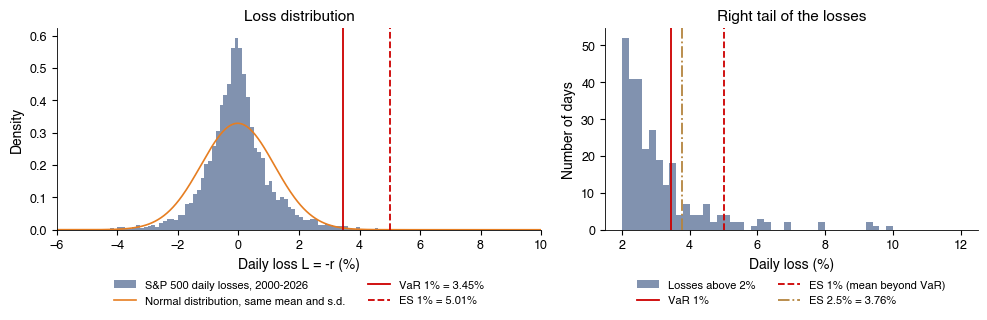

{'var1': np.float64(3.454548591009932),
 'es1': np.float64(5.0132950427498395),
 'var2_5': np.float64(2.5097631772393654),
 'es2_5': np.float64(3.7613189281197386),
 'n_beyond': 68,
 'N': 6717}

In [6]:
def fig_loss_distribution():
    L = loss['sp500']
    v, e = hs_var_es(L, 0.01)
    v2, e2 = hs_var_es(L, 0.025)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={'width_ratios': [1.3, 1]})
    ax = axes[0]
    bins = np.linspace(-8, 12, 161)
    ax.hist(L, bins=bins, density=True, color=MainBlue, alpha=0.55, label='S&P 500 daily losses, 2000-2026')
    x = np.linspace(-8, 12, 600)
    ax.plot(x, stats.norm.pdf(x, L.mean(), L.std()), color=Orange, lw=1.2, label='Normal distribution, same mean and s.d.')
    ax.axvline(v, color=IDAred, lw=1.3, label=f'VaR 1% = {v:.2f}%')
    ax.axvline(e, color=IDAred, lw=1.3, ls='--', label=f'ES 1% = {e:.2f}%')
    ax.set_xlim(-6, 10)
    ax.set_xlabel('Daily loss L = -r (%)')
    ax.set_ylabel('Density')
    ax.set_title('Loss distribution')
    legend_outside_bottom(ax, 2, -0.2)
    ax = axes[1]
    tail = L[L > 2]
    ax.hist(tail, bins=np.linspace(2, 12, 51), color=MainBlue, alpha=0.55, label='Losses above 2%')
    ax.axvline(v, color=IDAred, lw=1.3, label='VaR 1%')
    ax.axvline(e, color=IDAred, lw=1.3, ls='--', label='ES 1% (mean beyond VaR)')
    ax.axvline(e2, color=Amber, lw=1.3, ls='-.', label=f'ES 2.5% = {e2:.2f}%')
    ax.set_xlabel('Daily loss (%)')
    ax.set_ylabel('Number of days')
    ax.set_title('Right tail of the losses')
    legend_outside_bottom(ax, 2, -0.2)
    plt.tight_layout()
    save_fig('ch7_loss_distribution')
    return dict(var1=v, es1=e, var2_5=v2, es2_5=e2, n_beyond=int((L >= v).sum()), N=len(L))


fig_loss_distribution()

## 2. Subadditivity: two bonds

- Each bond loses 100 with probability 0.9%; VaR 1% of the portfolio exceeds the sum of the stand-alone VaRs.

{'p': 0.009, 'lgd': 100.0, 'alpha': 0.01, 'var1': np.float64(0.0), 'es1': np.float64(89.99999999999999), 'varP': np.float64(100.0), 'esP': np.float64(100.81000000000002), 'p_any': 0.017919000000000018, 'p_both': 8.099999999999999e-05}


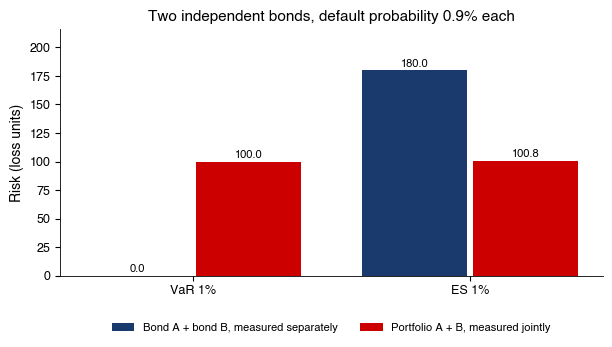

In [7]:
def discrete_var_es(values, probs, alpha):
    """VaR and ES at tail probability alpha for a discrete loss L = -X (Acerbi-Tasche formula).
    VaR_alpha = -inf{x : P(X <= x) > alpha}; ES_alpha = (E[L 1{L > VaR}] + VaR (alpha - P(L > VaR))) / alpha."""
    order = np.argsort(values)
    x, p = np.asarray(values)[order], np.asarray(probs)[order]
    cdf = np.cumsum(p)
    var = x[np.searchsorted(cdf, 1 - alpha - 1e-12)]
    tail = x > var
    es = ((x[tail] * p[tail]).sum() + var * (alpha - p[tail].sum())) / alpha
    return var, es


def bonds_example(p=0.009, lgd=100.0, alpha=0.01):
    """Two independent bonds; each loses lgd with probability p."""
    single = discrete_var_es([0, lgd], [1 - p, p], alpha)
    port = discrete_var_es([0, lgd, 2 * lgd], [(1 - p) ** 2, 2 * p * (1 - p), p ** 2], alpha)
    return dict(p=p, lgd=lgd, alpha=alpha, var1=single[0], es1=single[1], varP=port[0], esP=port[1],
                p_any=1 - (1 - p) ** 2, p_both=p ** 2)


def fig_subadditivity(ex):
    fig, ax = plt.subplots(figsize=(7, 3.2))
    lab = ['VaR 1%', 'ES 1%']
    sums = [2 * ex['var1'], 2 * ex['es1']]
    port = [ex['varP'], ex['esP']]
    xx = np.arange(2)
    ax.bar(xx - 0.2, sums, 0.38, color=MainBlue, label='Bond A + bond B, measured separately')
    ax.bar(xx + 0.2, port, 0.38, color=IDAred, label='Portfolio A + B, measured jointly')
    for i in range(2):
        ax.text(xx[i] - 0.2, sums[i] + 3, f'{sums[i]:.1f}', ha='center', fontsize=8)
        ax.text(xx[i] + 0.2, port[i] + 3, f'{port[i]:.1f}', ha='center', fontsize=8)
    ax.set_xticks(xx)
    ax.set_xticklabels(lab)
    ax.set_ylabel('Risk (loss units)')
    ax.set_ylim(0, max(sums + port) * 1.2)
    ax.set_title('Two independent bonds, default probability 0.9% each')
    legend_outside_bottom(ax, 2, -0.15)
    save_fig('ch7_subadditivity')


ex = bonds_example()
print(ex)
fig_subadditivity(ex)

## 3. Five methods across tail probabilities

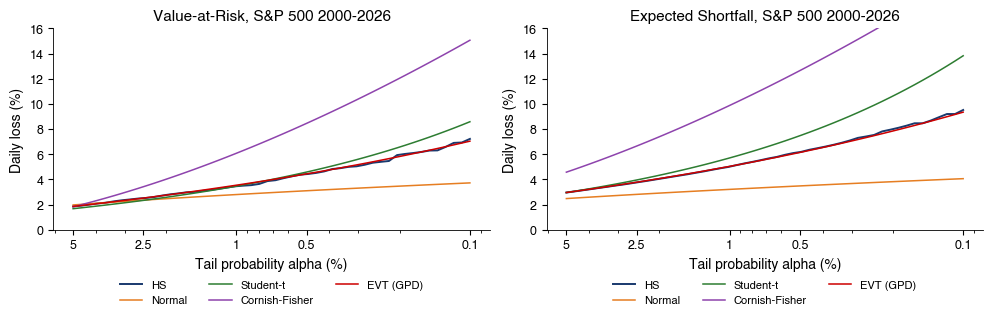

{'HS': {'var0_1': np.float64(7.218793981945014),
  'es0_1': np.float64(9.517897042601891)},
 'Normal': {'var0_1': np.float64(3.7229985890136477),
  'es0_1': np.float64(4.058760271918993)},
 'Student-t': {'var0_1': np.float64(8.583556952179416),
  'es0_1': np.float64(13.827183560491491)},
 'Cornish-Fisher': {'var0_1': np.float64(15.061768591099108),
  'es0_1': np.float64(20.066678146813988)},
 'EVT (GPD)': {'var0_1': np.float64(7.040115326259686),
  'es0_1': np.float64(9.345705164546002)}}

In [8]:
def fig_var_levels():
    L = loss['sp500']
    levels = np.geomspace(0.05, 0.001, 50)     # tail probability alpha, from 5% down to 0.1%
    f = gpd_fit(L, 0.05)
    tp = t_fit(L)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    curves = {}
    for meth in METHODS:
        vv, ee = [], []
        for a in levels:
            if meth == 'HS':
                v, e = hs_var_es(L, a)
            elif meth == 'Normal':
                v, e = normal_var_es(L, a)
            elif meth == 'Student-t':
                v, e = t_var_es(L, a, tp)
            elif meth == 'Cornish-Fisher':
                v, e = cf_var_es(L, a)
            else:
                v, e = gpd_var_es(f, a)
            vv.append(v)
            ee.append(e)
        curves[meth] = (vv, ee)
        axes[0].plot(100 * levels, vv, color=METHOD_COL[meth], lw=1.4 if meth == 'HS' else 1.1, label=meth)
        axes[1].plot(100 * levels, ee, color=METHOD_COL[meth], lw=1.4 if meth == 'HS' else 1.1, label=meth)
    for ax, t in zip(axes, ['Value-at-Risk', 'Expected Shortfall']):
        ax.set_xscale('log')
        ax.invert_xaxis()
        ax.set_xticks([5, 2.5, 1, 0.5, 0.1])
        ax.set_xticklabels(['5', '2.5', '1', '0.5', '0.1'])
        ax.set_xlabel('Tail probability alpha (%)')
        ax.set_ylabel('Daily loss (%)')
        ax.set_title(f'{t}, S&P 500 2000-2026')
        ax.set_ylim(0, 16)
        legend_outside_bottom(ax, 3, -0.2)
    plt.tight_layout()
    save_fig('ch7_var_levels')
    return {m: dict(var0_1=curves[m][0][-1], es0_1=curves[m][1][-1]) for m in METHODS}


fig_var_levels()

## 4. VaR and ES by method and asset

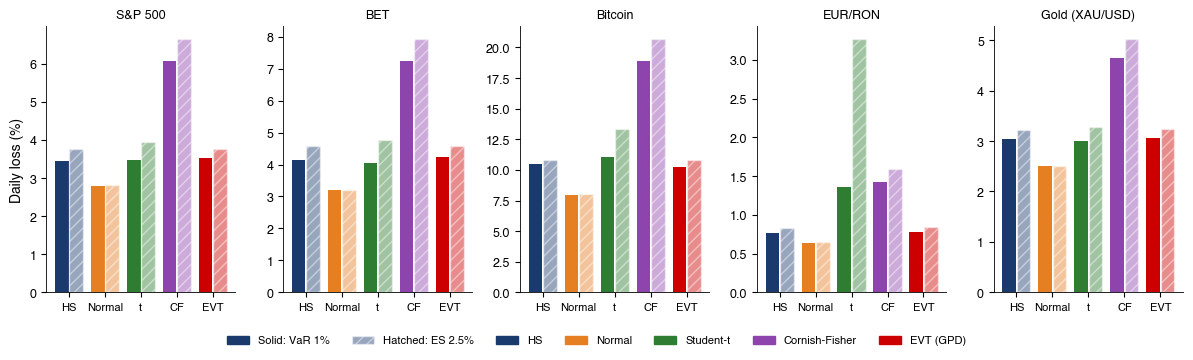

,sp500,bet,btc,eurron,gold
HS|VaR 1%,3.45,4.13,10.51,0.76,3.04
HS|ES 1%,5.01,6.28,14.29,1.12,4.21
Normal|VaR 1%,2.80,3.19,7.99,0.64,2.50
Normal|ES 1%,3.21,3.66,9.17,0.74,2.87
Student-t|VaR 1%,3.46,4.06,11.06,1.36,3.00
Student-t|ES 1%,5.71,7.08,20.46,6.81,4.46
Cornish-Fisher|VaR 1%,6.08,7.25,18.89,1.43,4.64
Cornish-Fisher|ES 1%,9.88,11.75,30.87,2.49,7.23
EVT (GPD)|VaR 1%,3.54,4.22,10.23,0.78,3.07
EVT (GPD)|ES 1%,5.04,6.34,14.36,1.14,4.22


In [9]:
def all_methods(L, alpha):
    """VaR and ES at level alpha for all unconditional methods."""
    f = gpd_fit(L, 0.05)
    return {'HS': hs_var_es(L, alpha), 'Normal': normal_var_es(L, alpha), 'Student-t': t_var_es(L, alpha),
            'Cornish-Fisher': cf_var_es(L, alpha), 'EVT (GPD)': gpd_var_es(f, alpha)}


def summary_table():
    """Descriptive statistics and VaR/ES (1%, 2.5%) by method for the five series."""
    rows = {}
    for k in ORDER:
        L = loss[k]
        nu, m, s = t_fit(L)
        f = gpd_fit(L, 0.05)
        row = dict(N=len(L), start=str(L.index[0].date()), mean=L.mean(), sd=L.std(), skew=stats.skew(L),
                   kurt=stats.kurtosis(L), max=L.max(), max_date=str(L.idxmax().date()), t_nu=nu, t_loc=m, t_scale=s,
                   gpd_u=f['u'], gpd_xi=f['xi'], gpd_beta=f['beta'], gpd_nu=f['nu'],
                   gpd_xi_se=gpd_se(f)[0], ppy=periods_per_year(L))
        for a, tag in [(0.01, '1%'), (0.025, '2.5%')]:
            for meth, (v, e) in all_methods(L, a).items():
                row[f'{meth}|VaR {tag}'] = v
                row[f'{meth}|ES {tag}'] = e
        rows[k] = row
    t = pd.DataFrame(rows).T
    t.to_csv(os.path.join(HERE, 'ch7_var_es_table.csv'))
    return t


def fig_methods_assets(t):
    fig, axes = plt.subplots(1, 5, figsize=(12, 3.3))
    for ax, k in zip(axes, ORDER):
        vals = [t.loc[k, f'{m}|VaR 1%'] for m in METHODS]
        es = [t.loc[k, f'{m}|ES 2.5%'] for m in METHODS]
        xx = np.arange(len(METHODS))
        ax.bar(xx - 0.2, vals, 0.38, color=[METHOD_COL[m] for m in METHODS])
        ax.bar(xx + 0.2, es, 0.38, color=[METHOD_COL[m] for m in METHODS], alpha=0.45, hatch='///', edgecolor='white')
        ax.set_xticks(xx)
        ax.set_xticklabels(['HS', 'Normal', 't', 'CF', 'EVT'], fontsize=8)
        ax.set_title(LABELS[k].replace(' (reference rate)', ''), fontsize=9)
        if k == ORDER[0]:
            ax.set_ylabel('Daily loss (%)')
    from matplotlib.patches import Patch
    h = [Patch(color=MainBlue, label='Solid: VaR 1%'), Patch(facecolor=MainBlue, alpha=0.45, hatch='///', edgecolor='white',
                                                             label='Hatched: ES 2.5%')]
    h += [Patch(color=METHOD_COL[m], label=m) for m in METHODS]
    fig.legend(handles=h, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=7, frameon=False)
    plt.tight_layout()
    save_fig('ch7_methods_assets')


t = summary_table()
fig_methods_assets(t)
t[[c for c in t.columns if '|' in c]].astype(float).round(2).T

In [10]:
# Moments, Student-t and GPD parameters
t[['N', 'mean', 'sd', 'skew', 'kurt', 'max', 'max_date', 't_nu', 'gpd_u', 'gpd_xi', 'gpd_xi_se']]

,N,mean,sd,skew,kurt,max,max_date,t_nu,gpd_u,gpd_xi,gpd_xi_se
sp500,6717,-0.024708,1.212759,0.348375,10.672207,12.765218,2020-03-16,2.666439,1.852232,0.187862,0.064803
bet,6670,-0.063931,1.398639,0.653293,11.062947,13.116763,2009-01-07,2.426043,1.934186,0.20918,0.066163
btc,4384,-0.118056,3.485192,0.704892,11.95772,46.473021,2020-03-12,2.229245,5.33101,0.163785,0.078462
eurron,5352,-0.007108,0.279412,-0.725478,15.138516,2.540081,2008-10-09,1.248979,0.37702,0.18309,0.072269
gold,6956,-0.03908,1.092198,0.251998,7.70288,11.140951,2026-01-30,3.320371,1.679163,0.154889,0.061909


## 5. Historical vs filtered historical simulation

- AR(1)-GARCH(1,1) re-estimated every January on all earlier data; FHS and conditional EVT use the earlier standardised residuals.

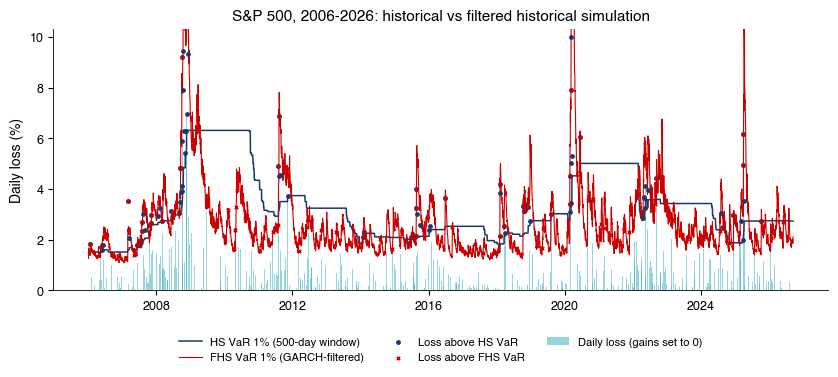

{'n': 5210,
 'exc_hs': 0.016698656429942418,
 'exc_fhs': 0.015355086372360844,
 'exc_cevt': 0.013435700575815739,
 'exc_ng': 0.023416506717850286,
 'hs_min': 1.4947895409434182,
 'hs_max': 6.3169285901881125,
 'fhs_min': 1.0876974622498612,
 'fhs_max': 18.013509852113067,
 'fhs_max_date': '2020-03-18',
 'first': '2006-01-03',
 'last': '2026-09-18'}

In [11]:
def fig_rolling(name, d, fname, title, start):
    d = d.loc[start:]
    fig, ax = plt.subplots(figsize=(10, 3.4))
    ax.bar(d.index, d['loss'].clip(lower=0), width=1.5, color=Teal, alpha=0.45, label='Daily loss (gains set to 0)')
    ax.plot(d.index, d['hs_var'], color=MainBlue, lw=1.1, label='HS VaR 1% (500-day window)')
    ax.plot(d.index, d['fhs_var'], color=IDAred, lw=0.8, label='FHS VaR 1% (GARCH-filtered)')
    exc_h = d['loss'] > d['hs_var']
    exc_f = d['loss'] > d['fhs_var']
    ax.scatter(d.index[exc_h], d['loss'][exc_h], s=6, color=MainBlue, zorder=3, label='Loss above HS VaR')
    ax.scatter(d.index[exc_f], d['loss'][exc_f], s=6, marker='x', color=IDAred, zorder=3, label='Loss above FHS VaR')
    ax.set_ylabel('Daily loss (%)')
    ax.set_title(title)
    ax.set_ylim(0, np.percentile(d['loss'], 99.95) * 1.1)
    legend_outside_bottom(ax, 3, -0.14)
    save_fig(fname)
    return dict(n=len(d), exc_hs=float(exc_h.mean()), exc_fhs=float(exc_f.mean()),
                exc_cevt=float((d['loss'] > d['cevt_var']).mean()), exc_ng=float((d['loss'] > d['ngarch_var']).mean()),
                hs_min=float(d['hs_var'].min()), hs_max=float(d['hs_var'].max()),
                fhs_min=float(d['fhs_var'].min()), fhs_max=float(d['fhs_var'].max()),
                fhs_max_date=str(d['fhs_var'].idxmax().date()), first=str(d.index[0].date()),
                last=str(d.index[-1].date()))


d_sp = rolling_conditional(rets['sp500'], 2004)
fig_rolling('sp500', d_sp, 'ch7_hs_fhs_sp500', 'S&P 500, 2006-2026: historical vs filtered historical simulation', '2006-01-01')

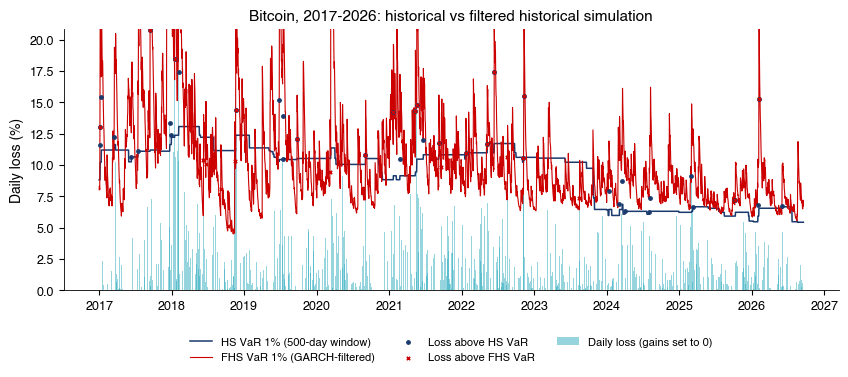

{'n': 3548,
 'exc_hs': 0.011555806087936866,
 'exc_fhs': 0.007609921082299887,
 'exc_cevt': 0.007609921082299887,
 'exc_ng': 0.015783540022547914,
 'hs_min': 5.430238041166156,
 'hs_max': 13.060173002801491,
 'fhs_min': 4.496459837263521,
 'fhs_max': 54.82611928974306,
 'fhs_max_date': '2020-03-13',
 'first': '2017-01-01',
 'last': '2026-09-18'}

In [12]:
d_btc = rolling_conditional(rets['btc'], 2017)
fig_rolling('btc', d_btc, 'ch7_hs_fhs_btc', 'Bitcoin, 2017-2026: historical vs filtered historical simulation', '2017-01-01')

## 6. Conditional VaR and ES for the next trading day

In [13]:
def conditional_now():
    out = {}
    for k in ORDER:
        r = rets[k]
        params, mu, sig = garch_filter(r)
        z = ((r - mu) / sig).dropna()
        nz = -z.values
        m1, s1 = garch_next(r, params)
        fz = gpd_fit(nz, 0.10)
        row = dict(mu=m1, sigma=s1, sigma_uncond=r.std(), omega=params.iloc[2], alpha=params.iloc[3], beta=params.iloc[4],
                   phi=params.iloc[1], zxi=fz['xi'])
        for a, tag in [(0.01, '1'), (0.025, '2_5')]:
            q = np.quantile(nz, 1 - a)
            row[f'fhs_var{tag}'] = -m1 + s1 * q
            row[f'fhs_es{tag}'] = -m1 + s1 * nz[nz >= q].mean()
            v, e = gpd_var_es(fz, a)
            row[f'cevt_var{tag}'] = -m1 + s1 * v
            row[f'cevt_es{tag}'] = -m1 + s1 * e
            row[f'ng_var{tag}'] = -m1 + s1 * stats.norm.ppf(1 - a)
            row[f'ng_es{tag}'] = -m1 + s1 * stats.norm.pdf(stats.norm.ppf(a)) / a
            row[f'zq{tag}'] = q
        out[k] = row
    pd.DataFrame(out).T.to_csv(os.path.join(HERE, 'ch7_conditional_now.csv'))
    return out


pd.DataFrame(conditional_now()).round(3)

,sp500,bet,btc,eurron,gold
mu,0.056,0.308,0.093,0.016,0.016
sigma,0.725,1.764,3.001,0.106,1.433
sigma_uncond,1.213,1.399,3.485,0.279,1.092
omega,0.025,0.046,0.502,0.002,0.013
alpha,0.120,0.207,0.127,0.200,0.046
beta,0.860,0.787,0.843,0.780,0.943
phi,-0.053,0.104,-0.009,0.169,-0.022
zxi,0.027,0.104,0.162,0.091,0.055
fhs_var1,1.968,4.528,8.556,0.274,3.821
fhs_es1,2.551,6.162,12.216,0.343,4.944


## 7. The horizon: square-root-of-time and filtered Monte Carlo

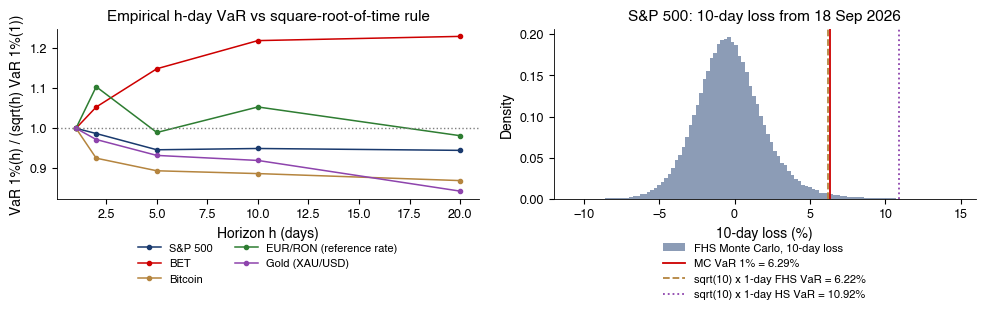

{'mc_var': np.float64(6.292), 'mc_es': np.float64(8.186), 'mc_es2_5': np.float64(6.516), 'sqrt_var': np.float64(6.224), 'one_day': np.float64(1.968), 'uncond_var': np.float64(10.924), 'sigma_now': np.float64(0.725), 'sigma_uncond': 1.213}


,sp500,bet,btc,eurron,gold
1,1.000,1.000,1.000,1.000,1.000
es1,1.000,1.000,1.000,1.000,1.000
2,0.987,1.053,0.925,1.104,0.972
es2,0.954,1.047,0.966,1.066,0.985
5,0.946,1.149,0.894,0.990,0.932
es5,0.933,1.094,0.916,1.001,0.930
10,0.950,1.219,0.887,1.053,0.920
es10,0.937,1.128,0.893,0.991,0.879
20,0.945,1.230,0.869,0.982,0.843
es20,0.925,1.156,0.822,0.899,0.809


In [14]:
def horizon_ratios(hs=(1, 2, 5, 10, 20)):
    """Empirical h-day VaR 1% (overlapping sums) divided by sqrt(h) times the one-day VaR 1%."""
    out = {}
    for k in ORDER:
        r = rets[k]
        v1 = hs_var_es(-r, 0.01)[0]
        e1 = hs_var_es(-r, 0.025)[1]
        row = {}
        for h in hs:
            rh = r.rolling(h).sum().dropna()
            row[h] = hs_var_es(-rh, 0.01)[0] / (np.sqrt(h) * v1)
            row[f'es{h}'] = hs_var_es(-rh, 0.025)[1] / (np.sqrt(h) * e1)
        acf1 = r.autocorr(1)
        row['rho1'] = acf1
        out[k] = row
    return out


def mc_horizon(k='sp500', h=10):
    r = rets[k]
    params, mu, sig = garch_filter(r)
    z = ((r - mu) / sig).dropna().values
    sim = fhs_mc(r, params, z, h, n_paths=200_000, seed=SEED)
    m1, s1 = garch_next(r, params)
    nz = -z
    v1 = -m1 + s1 * np.quantile(nz, 1 - 0.01)
    mc_var, mc_es = hs_var_es(sim, 0.01)
    return dict(sim=sim, mc_var=mc_var, mc_es=mc_es, mc_es2_5=hs_var_es(sim, 0.025)[1], sqrt_var=np.sqrt(h) * v1,
                one_day=v1, uncond_var=np.sqrt(h) * hs_var_es(-r, 0.01)[0], sigma_now=s1, sigma_uncond=r.std())


def fig_horizon(ratios, mc):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    ax = axes[0]
    cols = {'sp500': MainBlue, 'bet': IDAred, 'btc': Amber, 'eurron': Forest, 'gold': Purple}
    hs = [1, 2, 5, 10, 20]
    for k in ORDER:
        ax.plot(hs, [ratios[k][h] for h in hs], marker='o', ms=3, color=cols[k], label=LABELS[k])
    ax.axhline(1, color=Gray, ls=':', lw=1)
    ax.set_xlabel('Horizon h (days)')
    ax.set_ylabel('VaR 1%(h) / (sqrt(h) VaR 1%(1))')
    ax.set_title('Empirical h-day VaR vs square-root-of-time rule')
    legend_outside_bottom(ax, 2, -0.2)
    ax = axes[1]
    ax.hist(mc['sim'], bins=200, density=True, color=MainBlue, alpha=0.5, label='FHS Monte Carlo, 10-day loss')
    ax.axvline(mc['mc_var'], color=IDAred, lw=1.3, label=f"MC VaR 1% = {mc['mc_var']:.2f}%")
    ax.axvline(mc['sqrt_var'], color=Amber, lw=1.3, ls='--', label=f"sqrt(10) x 1-day FHS VaR = {mc['sqrt_var']:.2f}%")
    ax.axvline(mc['uncond_var'], color=Purple, lw=1.3, ls=':', label=f"sqrt(10) x 1-day HS VaR = {mc['uncond_var']:.2f}%")
    ax.set_xlim(-12, 16)
    ax.set_xlabel('10-day loss (%)')
    ax.set_ylabel('Density')
    ax.set_title('S&P 500: 10-day loss from 18 Sep 2026')
    legend_outside_bottom(ax, 1, -0.2)
    plt.tight_layout()
    save_fig('ch7_horizon')


ratios = horizon_ratios()
mc = mc_horizon()
fig_horizon(ratios, mc)
print({k: round(v, 3) for k, v in mc.items() if k != 'sim'})
pd.DataFrame(ratios).round(3)

## 8. Portfolio VaR and Euler contributions

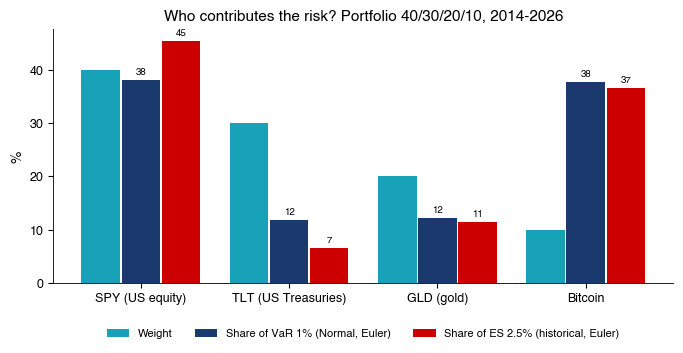

{'start': '2014-09-19',
 'N': 3017,
 'sd': array([1.10027871, 0.92638912, 1.02696406, 4.13716173]),
 'corr': array([[ 1.        , -0.17448097,  0.06755407,  0.2259404 ],
        [-0.17448097,  1.        ,  0.25368085, -0.01907467],
        [ 0.06755407,  0.25368085,  1.        ,  0.09489908],
        [ 0.2259404 , -0.01907467,  0.09489908,  1.        ]]),
 'sigma_p': np.float64(0.7594703155142161),
 'var_p': np.float64(1.766792153893623),
 'mvar': array([1.68167296, 0.69618202, 1.08491733, 6.68284896]),
 'cvar': array([0.67266919, 0.20885461, 0.21698347, 0.6682849 ]),
 'cvar_share': array([0.3807291 , 0.11821119, 0.12281211, 0.3782476 ]),
 'var_undiv': np.float64(3.1106463011245706),
 'es_p': np.float64(2.152045402856024),
 'var_hs': np.float64(1.478098816803344),
 'ces': array([0.97806804, 0.14027016, 0.24601923, 0.78768797]),
 'ces_share': array([0.45448299, 0.06517993, 0.11431879, 0.36601829]),
 'es_undiv': np.float64(3.8711619612931383)}

In [15]:
PORT = ['SPY', 'TLT', 'GLD', 'BTC']
W = np.array([0.40, 0.30, 0.20, 0.10])


def portfolio_components():
    lr = joint_returns(PORT, start='2014-09-18')
    R = 100 * (np.exp(lr) - 1)           # simple returns (%), which aggregate across the portfolio
    rp = R.values @ W
    Lp = -rp
    z1 = stats.norm.ppf(1 - 0.01)         # z_{1-alpha}, alpha = 1%
    S = np.cov(R.values.T)
    sp = np.sqrt(W @ S @ W)
    mvar = z1 * (S @ W) / sp            # marginal VaR (Normal, mean ignored)
    cvar = W * mvar                      # component VaR; the sum equals the portfolio VaR
    var_p = z1 * sp
    var_ind = z1 * np.sqrt(np.diag(S)) * W
    # historical component ES: E[-w_i R_i | L_p >= VaR_p]
    v_hs, es_hs = hs_var_es(Lp, 0.025)
    tail = Lp >= v_hs
    ces = -(R.values[tail] * W).mean(axis=0)
    es_ind = np.array([hs_var_es(-R.values[:, i] * W[i], 0.025)[1] for i in range(len(W))])
    corr = np.corrcoef(R.values.T)
    return dict(start=str(lr.index[0].date()), N=len(lr), sd=np.sqrt(np.diag(S)), corr=corr, sigma_p=sp, var_p=var_p,
                mvar=mvar, cvar=cvar, cvar_share=cvar / var_p, var_undiv=var_ind.sum(), es_p=es_hs, var_hs=v_hs,
                ces=ces, ces_share=ces / es_hs, es_undiv=es_ind.sum())


def fig_components(pc):
    fig, ax = plt.subplots(figsize=(8, 3.3))
    xx = np.arange(len(PORT))
    ax.bar(xx - 0.27, 100 * W, 0.26, color=Teal, label='Weight')
    ax.bar(xx, 100 * pc['cvar_share'], 0.26, color=MainBlue, label='Share of VaR 1% (Normal, Euler)')
    ax.bar(xx + 0.27, 100 * pc['ces_share'], 0.26, color=IDAred, label='Share of ES 2.5% (historical, Euler)')
    for i in range(len(PORT)):
        ax.text(xx[i] + 0.27, 100 * pc['ces_share'][i] + 1, f"{100 * pc['ces_share'][i]:.0f}", ha='center', fontsize=7)
        ax.text(xx[i], 100 * pc['cvar_share'][i] + 1, f"{100 * pc['cvar_share'][i]:.0f}", ha='center', fontsize=7)
    ax.set_xticks(xx)
    ax.set_xticklabels(['SPY (US equity)', 'TLT (US Treasuries)', 'GLD (gold)', 'Bitcoin'])
    ax.set_ylabel('%')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title('Who contributes the risk? Portfolio 40/30/20/10, 2014-2026')
    legend_outside_bottom(ax, 3, -0.14)
    save_fig('ch7_components')


pc = portfolio_components()
fig_components(pc)
pc

## 9. Extreme value theory: mean excess, GPD tails, block maxima

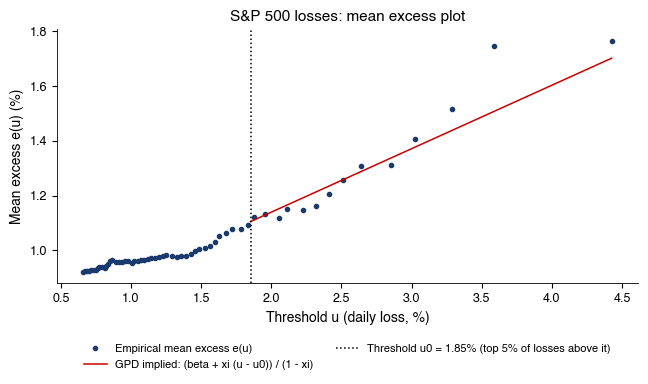

{'u': np.float64(1.8522316792378213), 'me_u': 1.0923205920336765}

In [16]:
def fig_mean_excess():
    L = loss['sp500'].values
    us = np.quantile(L, np.linspace(0.80, 0.995, 60))
    me, n = mean_excess(L, us)
    f = gpd_fit(L, 0.05)
    fig, ax = plt.subplots(figsize=(7.5, 3.3))
    ax.plot(us, me, 'o', ms=3, color=MainBlue, label='Empirical mean excess e(u)')
    uu = np.linspace(f['u'], us[-1], 50)
    ax.plot(uu, (f['beta'] + f['xi'] * (uu - f['u'])) / (1 - f['xi']), color=IDAred,
            label='GPD implied: (beta + xi (u - u0)) / (1 - xi)')
    ax.axvline(f['u'], color='black', ls=':', label=f"Threshold u0 = {f['u']:.2f}% (top 5% of losses above it)")
    ax.set_xlabel('Threshold u (daily loss, %)')
    ax.set_ylabel('Mean excess e(u) (%)')
    ax.set_title('S&P 500 losses: mean excess plot')
    legend_outside_bottom(ax, 2, -0.2)
    save_fig('ch7_mean_excess')
    return dict(u=f['u'], me_u=float(me[np.argmin(np.abs(us - f['u']))]))


fig_mean_excess()

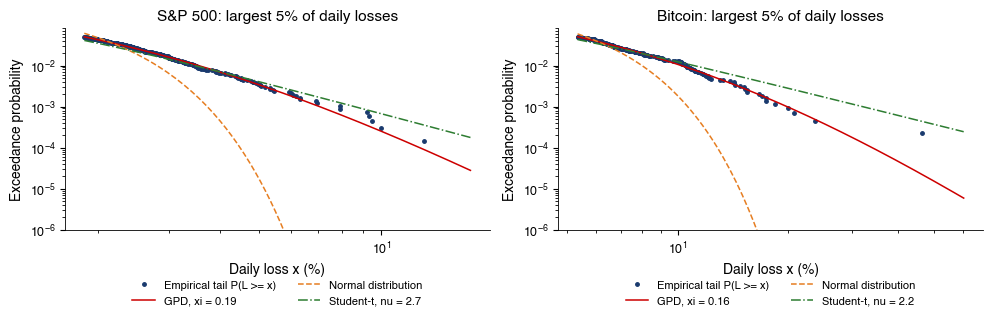

In [17]:
def fig_gpd_tail(t):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    for ax, k in zip(axes, ['sp500', 'btc']):
        L = loss[k].values
        f = gpd_fit(L, 0.05)
        xs = np.sort(L[L > f['u']])
        emp = 1 - np.arange(len(xs)) / len(xs)
        emp = emp * f['nu'] / f['n']
        ax.loglog(xs, emp, 'o', ms=2.5, color=MainBlue, label='Empirical tail P(L >= x)')
        xx = np.linspace(f['u'], xs[-1] * 1.3, 200)
        gp = f['nu'] / f['n'] * stats.genpareto.sf(xx - f['u'], f['xi'], scale=f['beta'])
        ax.loglog(xx, gp, color=IDAred, label=f"GPD, xi = {f['xi']:.2f}")
        ax.loglog(xx, stats.norm.sf(xx, L.mean(), L.std()), color=Orange, ls='--', label='Normal distribution')
        nu, m, s = t_fit(L)
        ax.loglog(xx, stats.t.sf(xx, nu, m, s), color=Forest, ls='-.', label=f'Student-t, nu = {nu:.1f}')
        ax.set_ylim(1e-6, 0.08)
        ax.set_xlabel('Daily loss x (%)')
        ax.set_ylabel('Exceedance probability')
        ax.set_title(f'{LABELS[k]}: largest 5% of daily losses')
        legend_outside_bottom(ax, 2, -0.2)
    plt.tight_layout()
    save_fig('ch7_gpd_tail')


fig_gpd_tail(t)

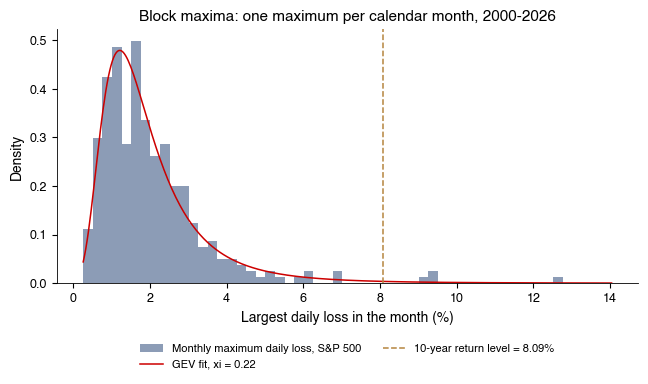

{'n_blocks': 321,
 'n_block': np.float64(20.925233644859812),
 'xi': np.float64(0.22346897986502817),
 'mu': np.float64(1.3663679777586983),
 'sigma': np.float64(0.7857493757954216),
 'rl10': np.float64(8.090070999808898),
 'rl30': np.float64(10.947655047101694),
 'var1': np.float64(2.8320495348728887),
 'var0_1': np.float64(6.192725266531509),
 'n_above_rl10': 4,
 'max': 12.76521830653392}

In [18]:
def fig_gev():
    L = loss['sp500']
    M = L.groupby([L.index.year, L.index.month]).max()
    n_block = L.groupby([L.index.year, L.index.month]).size().mean()
    c, loc, scale = stats.genextreme.fit(M.values)
    xi = -c
    rl10 = stats.genextreme.ppf(1 - 1 / 120, c, loc, scale)
    rl30 = stats.genextreme.ppf(1 - 1 / 360, c, loc, scale)
    var1 = stats.genextreme.ppf((1 - 0.01) ** n_block, c, loc, scale)       # VaR 1%
    var0_1 = stats.genextreme.ppf((1 - 0.001) ** n_block, c, loc, scale)    # VaR 0.1%
    fig, ax = plt.subplots(figsize=(7.5, 3.3))
    ax.hist(M.values, bins=50, density=True, color=MainBlue, alpha=0.5, label='Monthly maximum daily loss, S&P 500')
    x = np.linspace(M.min(), M.max() * 1.1, 400)
    ax.plot(x, stats.genextreme.pdf(x, c, loc, scale), color=IDAred, label=f'GEV fit, xi = {xi:.2f}')
    ax.axvline(rl10, color=Amber, ls='--', label=f'10-year return level = {rl10:.2f}%')
    ax.set_xlabel('Largest daily loss in the month (%)')
    ax.set_ylabel('Density')
    ax.set_title('Block maxima: one maximum per calendar month, 2000-2026')
    legend_outside_bottom(ax, 2, -0.2)
    save_fig('ch7_gev')
    return dict(n_blocks=len(M), n_block=n_block, xi=xi, mu=loc, sigma=scale, rl10=rl10, rl30=rl30, var1=var1,
                var0_1=var0_1, n_above_rl10=int((M > rl10).sum()), max=float(M.max()))


fig_gev()

## 10. Conditional EVT (McNeil and Frey)

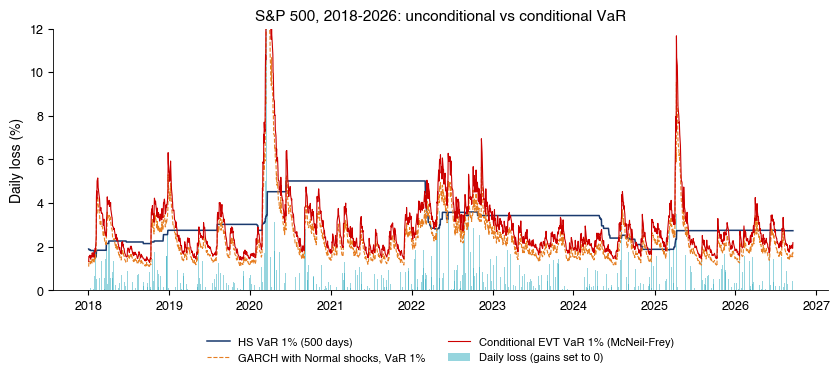

{'cevt_var': np.float64(0.0123),
 'ngarch_var': np.float64(0.0242),
 'hs_var': np.float64(0.016)}

In [19]:
def fig_cond_evt(d):
    d = d.loc['2018-01-01':]
    fig, ax = plt.subplots(figsize=(10, 3.4))
    ax.bar(d.index, d['loss'].clip(lower=0), width=1.5, color=Teal, alpha=0.45, label='Daily loss (gains set to 0)')
    ax.plot(d.index, d['hs_var'], color=MainBlue, lw=1.1, label='HS VaR 1% (500 days)')
    ax.plot(d.index, d['ngarch_var'], color=Orange, lw=0.8, ls='--', label='GARCH with Normal shocks, VaR 1%')
    ax.plot(d.index, d['cevt_var'], color=IDAred, lw=0.8, label='Conditional EVT VaR 1% (McNeil-Frey)')
    ax.set_ylabel('Daily loss (%)')
    ax.set_ylim(0, 12)
    ax.set_title('S&P 500, 2018-2026: unconditional vs conditional VaR')
    legend_outside_bottom(ax, 2, -0.14)
    save_fig('ch7_cond_evt')


fig_cond_evt(d_sp)
x = d_sp.loc['2018':]
{c: round((x['loss'] > x[c]).mean(), 4) for c in ['cevt_var', 'ngarch_var', 'hs_var']}

## 11. Basel: VaR 1% vs ES 2.5%

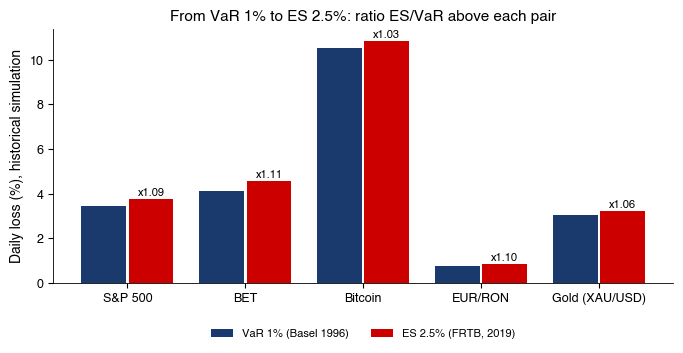

{'sp500': 1.0888018590643482,
 'bet': 1.1072069641949682,
 'btc': 1.0314269537938743,
 'eurron': 1.0961443950283787,
 'gold': 1.0605058726415517}

In [20]:
def fig_basel(t):
    fig, ax = plt.subplots(figsize=(8, 3.3))
    xx = np.arange(len(ORDER))
    v = np.array([t.loc[k, 'HS|VaR 1%'] for k in ORDER], dtype=float)
    e = np.array([t.loc[k, 'HS|ES 2.5%'] for k in ORDER], dtype=float)
    ax.bar(xx - 0.2, v, 0.38, color=MainBlue, label='VaR 1% (Basel 1996)')
    ax.bar(xx + 0.2, e, 0.38, color=IDAred, label='ES 2.5% (FRTB, 2019)')
    for i in range(len(ORDER)):
        ax.text(xx[i] + 0.2, e[i] + 0.15, f'x{e[i] / v[i]:.2f}', ha='center', fontsize=8)
    ax.set_xticks(xx)
    ax.set_xticklabels([LABELS[k].replace(' (reference rate)', '') for k in ORDER])
    ax.set_ylabel('Daily loss (%), historical simulation')
    ax.set_title('From VaR 1% to ES 2.5%: ratio ES/VaR above each pair')
    legend_outside_bottom(ax, 2, -0.14)
    save_fig('ch7_basel')
    return {k: float(e[i] / v[i]) for i, k in enumerate(ORDER)}


fig_basel(t)

## 12. Liquidity-adjusted VaR (illustration)

- Historical VaR 1% of Banca Transilvania over the last two years plus half of an assumed stressed spread.

In [21]:
SPREAD_MEAN, SPREAD_SD, SPREAD_A = 0.5, 0.3, 3.0   # assumed spread (%)


def liquidity(sym='TLV', position=1_000_000):
    """Historical VaR 1% over the last two years for a BVB stock + the cost of exiting the position at half the spread."""
    r = 100 * (np.exp(joint_returns([sym]).loc['2024-09-18':][sym]) - 1)   # simple returns: the exact money loss
    v = hs_var_es(-r, 0.01)[0]
    col = 0.5 * (SPREAD_MEAN + SPREAD_A * SPREAD_SD)
    return dict(sym=sym, N=len(r), var1=v, col=col, lvar=v + col, ratio=(v + col) / v,
                var_amt=v / 100 * position, col_amt=col / 100 * position, lvar_amt=(v + col) / 100 * position)


liquidity()

{'sym': 'TLV',
 'N': 496,
 'var1': np.float64(3.1580591119833117),
 'col': 0.7,
 'lvar': np.float64(3.8580591119833114),
 'ratio': np.float64(1.2216551290455069),
 'var_amt': np.float64(31580.591119833112),
 'col_amt': 6999.999999999999,
 'lvar_amt': np.float64(38580.591119833116)}

## 13. Inference for risk measures

- Asymptotic standard errors of historical VaR and ES (Chen, 2008), i.i.d. and HAC; Rockafellar–Uryasev and the minimum-ES linear program; worst-case VaR by the rearrangement algorithm; residual-bootstrap interval for today's FHS VaR; CAViaR; extremal index.

In [22]:
from scipy import optimize, signal


def nw_lrv(x):
    """Long-run variance (Newey-West, Bartlett kernel, lag floor(4 (n/100)^(2/9)))."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    m = int(np.floor(4 * (n / 100) ** (2 / 9)))
    s = x @ x / n
    for j in range(1, m + 1):
        s += 2 * (1 - j / (m + 1)) * (x[j:] @ x[:-j]) / n
    return s, m


def var_es_se(L, a_var=0.01, a_es=0.025):
    """Historical VaR: avar = a(1-a)/f(q)^2 (Gaussian kernel density, Silverman's rule);
    historical ES (Chen, 2008): influence function VaR + (L - VaR)_+/a - ES, avar = Var((L - VaR)_+)/a^2.
    HAC version: long-run variance of the indicator and of (L - VaR)_+, respectively."""
    L = np.asarray(L, float)
    n = len(L)
    v = np.quantile(L, 1 - a_var)
    f = stats.gaussian_kde(L, bw_method='silverman')(v)[0]
    ind = (L > v).astype(float)
    se_v = np.sqrt(a_var * (1 - a_var) / n) / f
    se_v_hac = np.sqrt(nw_lrv(ind)[0] / n) / f
    v2, e2 = hs_var_es(L, a_es)
    ex = np.maximum(L - v2, 0)
    se_e = ex.std(ddof=1) / (a_es * np.sqrt(n))
    lrv, m = nw_lrv(ex)
    se_e_hac = np.sqrt(lrv / n) / a_es
    return dict(n=n, var1=v, f=f, se_var=se_v, se_var_hac=se_v_hac, es=e2, var_es=v2, se_es=se_e,
                se_es_hac=se_e_hac, lag=m, ntail=a_es * n)


def se_theory(sigma=1.2, n=500, nu=4, alpha=0.01):
    """Asymptotic SE of the historical VaR 1% under the Normal distribution and under a Student-t (same standard deviation)."""
    z = stats.norm.ppf(1 - alpha)
    f_n = stats.norm.pdf(z) / sigma
    s = sigma * np.sqrt((nu - 2) / nu)
    q = stats.t.ppf(1 - alpha, nu)
    f_t = stats.t.pdf(q, nu) / s
    c = np.sqrt(alpha * (1 - alpha) / n)
    return dict(se_normal=c / f_n, se_t=c / f_t, q_normal=sigma * z, q_t=s * q)


def ru_objective(L, v, alpha):
    return v + np.maximum(np.asarray(L) - v, 0).mean() / alpha


def ru_check(L, alpha=0.025):
    L = np.asarray(L, float)
    res = optimize.minimize_scalar(lambda v: ru_objective(L, v, alpha), bounds=(0, L.max()), method='bounded',
                                   options=dict(xatol=1e-8))
    v, e = hs_var_es(L, alpha)
    return dict(argmin=res.x, min=res.fun, var=v, es=e)


def min_es_portfolio(R, alpha=0.025):
    """Minimum ES on scenarios (Rockafellar & Uryasev, 2000): min v + 1/(alpha N) sum u_s,
    u_s >= -R_s w - v, u_s >= 0, sum w = 1, w >= 0 (no short sales)."""
    N, d = R.shape
    c = np.concatenate([np.zeros(d), [1.0], np.full(N, 1 / (alpha * N))])
    from scipy.sparse import csr_matrix, hstack as sh, identity
    A = sh([csr_matrix(-R), csr_matrix(-np.ones((N, 1))), -identity(N)]).tocsr()
    b = np.zeros(N)
    Aeq = np.concatenate([np.ones(d), [0.0], np.zeros(N)])[None, :]
    bounds = [(0, None)] * d + [(None, None)] + [(0, None)] * N
    out = optimize.linprog(c, A_ub=A, b_ub=b, A_eq=Aeq, b_eq=[1.0], bounds=bounds, method='highs')
    return out.x[:d], out.x[d], out.fun


def min_var_portfolio(R):
    S = np.cov(R.T)
    d = S.shape[0]
    res = optimize.minimize(lambda w: w @ S @ w, np.full(d, 1 / d), bounds=[(0, 1)] * d,
                            constraints=[dict(type='eq', fun=lambda w: w.sum() - 1)], method='SLSQP',
                            options=dict(ftol=1e-14, maxiter=500))
    return res.x


def drop_largest(L, alpha_var=0.01, alpha_es=0.025):
    """Sensitivity to a single observation: historical VaR 1% and ES 2.5% with and without the largest loss."""
    L = np.asarray(L, float)
    L2 = np.delete(L, np.argmax(L))
    return dict(max=L.max(), var=np.quantile(L, 1 - alpha_var), var_drop=np.quantile(L2, 1 - alpha_var),
                es=hs_var_es(L, alpha_es)[1], es_drop=hs_var_es(L2, alpha_es)[1])


def rearrangement(X, tol=1e-10, max_iter=1000):
    X = X.copy()
    for _ in range(max_iter):
        old = X.copy()
        for j in range(X.shape[1]):
            rest = X.sum(axis=1) - X[:, j]
            X[np.argsort(rest), j] = np.sort(X[:, j])[::-1]    # order opposite to the sum of the other columns
        if np.max(np.abs(X - old)) < tol:
            break
    return X


def worst_var_ra(Lcols, alpha=0.01, N=2000):
    """Worst-case VaR 1% of a sum with given marginals (Embrechts, Puccetti & Rueschendorf, 2013):
    discretise the tail of probability alpha of each marginal in N points (lower / upper) and rearrange;
    worst VaR ~ minimum of the row sums."""
    lo = np.column_stack([np.quantile(x, 1 - alpha + alpha * np.arange(N) / N) for x in Lcols])
    hi = np.column_stack([np.quantile(x, 1 - alpha + alpha * np.arange(1, N + 1) / N) for x in Lcols])
    return rearrangement(lo).sum(axis=1).min(), rearrangement(hi).sum(axis=1).min()


def aggregation(alpha=0.01):
    W = np.array([0.40, 0.30, 0.20, 0.10])
    lr = joint_returns(['SPY', 'TLT', 'GLD', 'BTC'], start='2014-09-18')
    R = 100 * (np.exp(lr) - 1)
    Lw = [-(R.values[:, i] * W[i]) for i in range(4)]
    como = sum(np.quantile(x, 1 - alpha) for x in Lw)
    hist = np.quantile(-(R.values @ W), 1 - alpha)
    lo, hi = worst_var_ra(Lw, alpha)
    # minimum ES (LP) and the minimum-variance portfolio, alpha = 2.5%
    w_es, v_es, es_min = min_es_portfolio(R.values, 0.025)
    w_mv = min_var_portfolio(R.values)
    es_mv = hs_var_es(-(R.values @ w_mv), 0.025)[1]
    es_ew = hs_var_es(-(R.values @ W), 0.025)[1]
    sd_es = np.std(R.values @ w_es, ddof=1)
    sd_mv = np.std(R.values @ w_mv, ddof=1)
    return dict(N=len(R), var_hist=hist, var_como=como, var_worst_lo=lo, var_worst_hi=hi,
                w_es=w_es, es_min=es_min, v_es=v_es, w_mv=w_mv, es_mv=es_mv, es_4030=es_ew, sd_es=sd_es, sd_mv=sd_mv)


def fhs_bootstrap(r, alpha=0.01, B=999, seed=SEED, level=0.90, return_draws=False):
    """Christoffersen & Goncalves (2005): AR(1)-GARCH(1,1) paths with resampled residuals;
    re-estimate the parameters on each path; sigma_{T+1} from the ORIGINAL data with the bootstrap parameters;
    quantile from the standardised residuals of the bootstrap path."""
    rng = np.random.default_rng(seed)
    params, mu, sig = garch_filter(r)
    z = ((r - mu) / sig).dropna().values
    m1, s1 = garch_next(r, params)
    var0 = -m1 + s1 * np.quantile(-z, 1 - alpha)
    c, phi, om, al, be = params.values[:5]
    n = len(r)
    out = np.empty(B)
    parts = np.empty((B, 2))
    for b in range(B):
        zz = rng.choice(z, n)
        rs = np.empty(n)
        s2 = om / (1 - al - be)
        rp, ep = r.iloc[0], 0.0
        for t in range(n):
            s2 = om + al * ep ** 2 + be * s2 if t > 0 else s2
            e = np.sqrt(s2) * zz[t]
            rs[t] = c + phi * rp + e
            rp, ep = rs[t], e
        rs = pd.Series(rs, index=r.index)
        pb, mub, sgb = garch_filter(rs)
        zb = ((rs - mub) / sgb).dropna().values
        mb, sb = garch_next(r, pb)                    # ORIGINAL history, bootstrap parameters
        qb = np.quantile(-zb, 1 - alpha)
        out[b] = -mb + sb * qb
        parts[b] = [sb, qb]
    lo, hi = np.quantile(out, [(1 - level) / 2, (1 + level) / 2])
    # decomposition: quantile uncertainty only (sigma fixed) vs sigma uncertainty only (quantile fixed)
    q0 = np.quantile(-z, 1 - alpha)
    only_q = np.quantile(-m1 + s1 * parts[:, 1], [(1 - level) / 2, (1 + level) / 2])
    only_s = np.quantile(-m1 + parts[:, 0] * q0, [(1 - level) / 2, (1 + level) / 2])
    res = dict(var=var0, lo=lo, hi=hi, sd=out.std(ddof=1), B=B, level=level, sigma=s1,
                sig_lo=np.quantile(parts[:, 0], (1 - level) / 2), sig_hi=np.quantile(parts[:, 0], (1 + level) / 2),
                q=q0, q_lo=np.quantile(parts[:, 1], (1 - level) / 2), q_hi=np.quantile(parts[:, 1], (1 + level) / 2),
                onlyq_lo=only_q[0], onlyq_hi=only_q[1], onlys_lo=only_s[0], onlys_hi=only_s[1])
    return (res, out) if return_draws else res


def caviar_path(beta, r, v0):
    """VaR_t = b0 + b1 VaR_{t-1} + b2 |r_{t-1}| (positive VaR; quantile q_t = -VaR_t)."""
    b0, b1, b2 = beta
    x = b0 + b2 * np.abs(np.asarray(r, float)[:-1])
    rest = signal.lfilter([1.0], [1.0, -b1], x, zi=[b1 * v0])[0]
    return np.concatenate([[v0], rest])


def pinball(r, q, alpha):
    """Mean pinball (tick) loss for the return quantile q: (alpha - 1{r < q})(r - q)."""
    return np.mean((alpha - (r < q)) * (r - q))


def caviar_fit(r, alpha=0.01, n_rand=10_000, n_best=10, seed=SEED):
    """Engle & Manganelli (2004): 10^4 starting vectors U(0,1), the best 10 refined by alternating simplex
    and quasi-Newton steps until convergence; starting VaR = empirical quantile of the first 300 observations."""
    r = np.asarray(r, float)
    v0 = -np.quantile(r[:300], alpha)
    obj = lambda b: pinball(r, -caviar_path(b, r, v0), alpha) if abs(b[1]) < 1 else 1e6  # noqa: E731
    rng = np.random.default_rng(seed)
    cand = rng.uniform(0, 1, (n_rand, 3))
    vals = np.array([obj(b) for b in cand])
    best = []
    for b in cand[np.argsort(vals)[:n_best]]:
        f_old = np.inf
        for _ in range(20):
            b = optimize.minimize(obj, b, method='Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-12, maxiter=4000)).x
            b = optimize.minimize(obj, b, method='BFGS').x
            f = obj(b)
            if f_old - f < 1e-12:
                break
            f_old = f
        best.append((obj(b), b))
    f, b = min(best, key=lambda x: x[0])
    return b, v0, f


def caviar_study(name, est_end='2015-12-31', oos_start='2016-01-01', alpha=0.01, fhs=None):
    r = 100 * log_returns(name)
    b, v0, f = caviar_fit(r.loc[:est_end].values, alpha)
    v = pd.Series(caviar_path(b, r.values, v0), index=r.index)
    L = -r
    oos = r.loc[oos_start:].index
    out = dict(b0=b[0], b1=b[1], b2=b[2], n_est=int(len(r.loc[:est_end])), n_oos=int(len(oos)),
               hit_caviar=float((L.loc[oos] > v.loc[oos]).mean()),
               n_hit_caviar=int((L.loc[oos] > v.loc[oos]).sum()),
               pin_caviar=pinball(r.loc[oos].values, -v.loc[oos].values, alpha))
    if fhs is not None:
        d = fhs.loc[oos_start:]
        out.update(hit_fhs=float((d['loss'] > d['fhs_var']).mean()), n_hit_fhs=int((d['loss'] > d['fhs_var']).sum()),
                   pin_fhs=pinball(-d['loss'].values, -d['fhs_var'].values, alpha),
                   hit_hs=float((d['loss'] > d['hs_var']).mean()), n_hit_hs=int((d['loss'] > d['hs_var']).sum()),
                   pin_hs=pinball(-d['loss'].values, -d['hs_var'].values, alpha))
        cov = d.loc['2020-02-20':'2020-04-30']
        vc = v.loc[cov.index]
        out.update(covid_hit_caviar=int((cov['loss'] > vc).sum()), covid_hit_fhs=int((cov['loss'] > cov['fhs_var']).sum()),
                   covid_hit_hs=int((cov['loss'] > cov['hs_var']).sum()),
                   covid_max_caviar=float(vc.max()), covid_max_fhs=float(cov['fhs_var'].max()),
                   covid_max_hs=float(cov['hs_var'].max()), covid_days=int(len(cov)))
    return out, v


def fig_caviar(v, fhs, name='sp500', title='S&P 500', start='2016-01-01'):
    d = fhs.loc[start:]
    fig, ax = plt.subplots(figsize=(10, 3.3))
    ax.bar(d.index, d['loss'].clip(lower=0), width=1.5, color=Teal, alpha=0.45, label='Daily loss (gains set to 0)')
    ax.plot(d.index, v.loc[d.index], color=MainBlue, lw=0.9, label='CAViaR (SAV) VaR 1%, parameters from 2000-2015')
    ax.plot(d.index, d['fhs_var'], color=IDAred, lw=0.8, label='FHS VaR 1%, re-estimated every January')
    ax.set_ylabel('Daily loss (%)')
    ax.set_title(f'{title}, 2016-2026: one-day-ahead VaR 1% out of sample')
    legend_outside_bottom(ax, 3, -0.14)
    save_fig(f'ch7_caviar' if name == 'sp500' else f'ch7_sem_caviar_{name}')


def extremal_index(L, tail=0.05):
    """Intervals estimator: inter-exceedance times T_i; declustering with the C - 1 largest times,
    C = floor(theta N) + 1 (at most N); with ties, C is lowered until T_(C-1) > T_(C) (Ferro & Segers, 2003,
    Section 4); GPD on the cluster maxima."""
    L = np.asarray(L, float)
    u = np.quantile(L, 1 - tail)
    S = np.flatnonzero(L > u)
    T = np.diff(S).astype(float)
    N = len(S)
    if T.max() <= 2:
        th = 2 * T.sum() ** 2 / ((N - 1) * (T ** 2).sum())
    else:
        th = 2 * (T - 1).sum() ** 2 / ((N - 1) * ((T - 1) * (T - 2)).sum())
    th = min(1.0, th)
    C = min(int(np.floor(th * N)) + 1, N)                        # at most one cluster per exceedance
    cut = np.sort(T)[::-1][C - 2] if C > 1 else np.inf           # the (C-1)-th largest time
    breaks = np.flatnonzero(T > cut) if np.sum(T >= cut) > C - 1 else np.flatnonzero(T >= cut)
    groups = np.split(np.arange(N), breaks + 1)
    cmax = np.array([L[S[g]].max() for g in groups])
    xi, _, beta = stats.genpareto.fit(cmax - u, floc=0)
    fc = dict(u=u, xi=xi, beta=beta, nu=len(cmax), n=len(L))
    f = gpd_fit(L, tail)
    return dict(u=u, N=N, theta=th, n_clusters=len(groups), mean_size=N / len(groups),
                xi=f['xi'], se_xi=gpd_se(f)[0], xi_c=xi, se_xi_c=gpd_se(fc)[0], beta_c=beta,
                se_xi_eff=(1 + f['xi']) / np.sqrt(th * N))


def gev_theta(theta):
    """Daily VaR 1% from monthly maxima with the extremal-index correction: H^{-1}((1-alpha)^{n theta})."""
    r = 100 * log_returns('sp500')
    L = -r
    M = L.groupby([L.index.year, L.index.month]).max()
    n_block = L.groupby([L.index.year, L.index.month]).size().mean()
    c, loc, scale = stats.genextreme.fit(M.values)
    return dict(var1=stats.genextreme.ppf(0.99 ** n_block, c, loc, scale),
                var1_theta=stats.genextreme.ppf(0.99 ** (n_block * theta), c, loc, scale),
                pow_theta=0.99 ** (n_block * theta))


def seminar_extras():
    out = {}
    # Seminar A8: asymptotic variance of the historical ES 2.5% under N(0, 1): Var((L - v)_+) / alpha^2, truncated Normal moments
    a = 0.025
    v = stats.norm.ppf(1 - a)
    m1 = stats.norm.pdf(v) - v * a                       # E[(L - v)_+]
    m2 = (1 + v ** 2) * a - v * stats.norm.pdf(v)        # E[(L - v)_+^2]
    avar = (m2 - m1 ** 2) / a ** 2
    out['a8'] = dict(v=v, phi=stats.norm.pdf(v), m1=m1, m2=m2, var=m2 - m1 ** 2, avar=avar,
                     se500=np.sqrt(avar / 500), se500_pct=1.2 * np.sqrt(avar / 500), es=stats.norm.pdf(v) / a)
    # Seminar A6: monotonicity of the Cornish-Fisher map for z in [z_0.1%, 0]: derivative a z^2 + b z + c > 0
    def dmin(S, K):
        z = np.linspace(stats.norm.ppf(0.001), 0, 20001)
        return (1 + z * S / 3 + (3 * z ** 2 - 3) * K / 24 - (6 * z ** 2 - 5) * S ** 2 / 36).min()
    S = -0.5
    kmax = optimize.brentq(lambda K: dmin(S, K), 0.1, 30)
    kmax0 = optimize.brentq(lambda K: dmin(0.0, K), 0.1, 30)
    out['a6'] = dict(kmax=kmax, kmax0=kmax0, d3=dmin(S, 3.0), d10=dmin(S, 10.0))
    # Seminar A1: asymptotic SE of the historical VaR 1% under N(0.04, 1.2^2)
    z = stats.norm.ppf(0.01)
    out['a1'] = dict(f=stats.norm.pdf(z) / 1.2, se500=1.2 * np.sqrt(0.01 * 0.99 / 500) / stats.norm.pdf(z),
                     se6670=1.2 * np.sqrt(0.01 * 0.99 / 6670) / stats.norm.pdf(z))
    # Seminar B1 Extended: BET, VaR 1%: asymptotic interval (kernel density) and block bootstrap (20 days)
    L = (-100 * log_returns('bet')).values
    for tag, x in [('full', L), ('w500', L[-500:])]:
        se = var_es_se(x)
        ci_blk, _ = boot_ci(x, lambda y: hs_var_es(y, 0.01)[0], block=20)
        out[f'b1_{tag}'] = dict(var1=se['var1'], f=se['f'], se=se['se_var'], se_hac=se['se_var_hac'],
                                lo=se['var1'] - 1.96 * se['se_var'], hi=se['var1'] + 1.96 * se['se_var'],
                                lo_hac=se['var1'] - 1.96 * se['se_var_hac'], hi_hac=se['var1'] + 1.96 * se['se_var_hac'],
                                blk_lo=ci_blk[0], blk_hi=ci_blk[1])
    return out

In [23]:
L_sp = loss['sp500'].values
print(pd.DataFrame({'full': var_es_se(L_sp), 'last 500': var_es_se(L_sp[-500:])}).round(3))
print(se_theory(n=500))
print(ru_check(L_sp, 0.025))
print(drop_largest(L_sp[-500:]))
aggregation()

                full  last 500
n           6717.000   500.000
var1           3.455     2.734
f              0.010     0.012
se_var         0.126     0.358
se_var_hac     0.188     0.437
es             3.761     2.939
var_es         2.510     1.787
se_es          0.154     0.484
se_es_hac      0.255     0.650
lag           10.000     5.000
ntail        167.925    12.500
{'se_normal': np.float64(0.2003464813427291), 'se_t': np.float64(0.4348963297541458), 'q_normal': np.float64(2.7916174488490086), 'q_t': np.float64(3.17939028814882)}
{'argmin': np.float64(2.5107730883904438), 'min': np.float64(3.76187745685566), 'var': np.float64(2.5097631772393654), 'es': np.float64(3.7613189281197386)}
{'max': np.float64(6.160905396787442), 'var': np.float64(2.7344959630190093), 'var_drop': np.float64(2.6813083274414486), 'es': np.float64(2.9389510884292656), 'es_drop': np.float64(2.6015999439519506)}


{'N': 3017,
 'var_hist': np.float64(1.9532521396106948),
 'var_como': np.float64(3.6348672934758444),
 'var_worst_lo': np.float64(4.761475797796948),
 'var_worst_hi': np.float64(4.763820342766483),
 'w_es': array([0.3072158 , 0.44277253, 0.25001167, 0.        ]),
 'es_min': 1.6659527209186487,
 'v_es': np.float64(1.2085102963923986),
 'w_mv': array([0.34865398, 0.43237513, 0.21897088, 0.        ]),
 'es_mv': np.float64(1.6740299651263857),
 'es_4030': np.float64(2.152045402856024),
 'sd_es': np.float64(0.6043210434575225),
 'sd_mv': np.float64(0.601584173912214)}

In [24]:
# Residual bootstrap (999 re-estimated GARCH paths, about a minute)
fhs_bootstrap(rets['sp500'])

{'var': np.float64(1.9681591465235668),
 'lo': np.float64(1.8950076287387823),
 'hi': np.float64(2.09069359662901),
 'sd': np.float64(0.060637090508745925),
 'B': 999,
 'level': 0.9,
 'sigma': np.float64(0.7253001894582619),
 'sig_lo': np.float64(0.7078399194108571),
 'sig_hi': np.float64(0.7429805424358138),
 'q': np.float64(2.7912806192809416),
 'q_lo': np.float64(2.6769738386357598),
 'q_hi': np.float64(2.8772675670336034),
 'onlyq_lo': np.float64(1.8852524168652525),
 'onlyq_hi': np.float64(2.03052549601951),
 'onlys_lo': np.float64(1.9194226331328343),
 'onlys_hi': np.float64(2.0175099731318533)}

{'b0': np.float64(0.08977049550699856), 'b1': np.float64(0.8973133831532212), 'b2': np.float64(0.24579518708379283), 'n_est': 4024, 'n_oos': 2693, 'hit_caviar': 0.012996658002227999, 'n_hit_caviar': 35, 'pin_caviar': np.float64(0.03874086663398279), 'hit_fhs': 0.012996658002227999, 'n_hit_fhs': 35, 'pin_fhs': np.float64(0.03726175252914158), 'hit_hs': 0.014110657259561827, 'n_hit_hs': 38, 'pin_hs': np.float64(0.05243518329741645), 'covid_hit_caviar': 6, 'covid_hit_fhs': 3, 'covid_hit_hs': 9, 'covid_max_caviar': 13.53390536255776, 'covid_max_fhs': 18.013509852113067, 'covid_max_hs': 4.521748952527459, 'covid_days': 50}


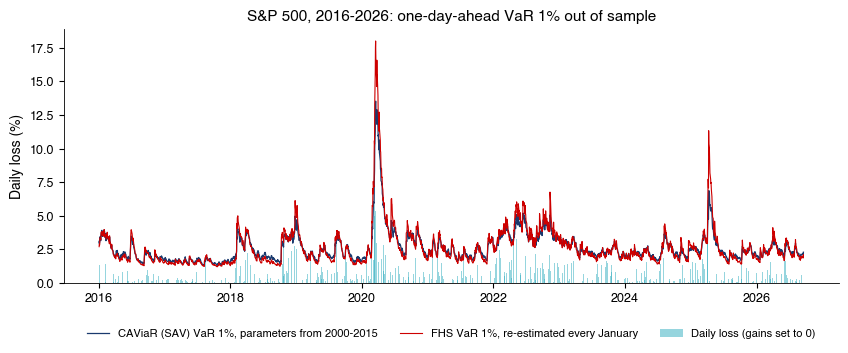

In [25]:
res, v = caviar_study('sp500', fhs=d_sp)
print(res)
fig_caviar(v, d_sp)

In [26]:
ei = extremal_index(L_sp, 0.05)
ei1 = extremal_index(L_sp, 0.01)
_p, _mu, _sg = garch_filter(rets['sp500'])
print(ei)
print(ei1)
print(extremal_index(-((rets['sp500'] - _mu) / _sg).dropna().values, 0.05))
gev_theta(ei1['theta'])

{'u': np.float64(1.8522316792378213), 'N': 336, 'theta': np.float64(0.1873770683848363), 'n_clusters': 62, 'mean_size': 5.419354838709677, 'xi': np.float64(0.18786249341888944), 'se_xi': np.float64(0.06480321180108387), 'xi_c': np.float64(0.15228318771682794), 'se_xi_c': np.float64(0.1463401111802215), 'beta_c': np.float64(1.2786438007017276), 'se_xi_eff': np.float64(0.14970569132397676)}
{'u': np.float64(3.454548591009932), 'N': 68, 'theta': np.float64(0.35211669284309494), 'n_clusters': 23, 'mean_size': 2.9565217391304346, 'xi': np.float64(0.21449550356868563), 'se_xi': np.float64(0.1472792130309236), 'xi_c': np.float64(0.37715092864996036), 'se_xi_c': np.float64(0.2871558189556029), 'beta_c': np.float64(1.0524597736658947), 'se_xi_eff': np.float64(0.2481979258182983)}
{'u': np.float64(1.7534503454660932), 'N': 336, 'theta': np.float64(0.9936013510959998), 'n_clusters': 320, 'mean_size': 1.05, 'xi': np.float64(0.023464996396749135), 'se_xi': np.float64(0.05583459306102153), 'xi_c': n

{'var1': np.float64(2.8320495348728887),
 'var1_theta': np.float64(4.14079423938143),
 'pow_theta': np.float64(0.9286232913469208)}